In [87]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
from matplotlib import pyplot as plt

from libs.librating import Report

In [88]:
report = Report(file_name="ipa_report_new.txt")

In [89]:
report.raw_table

,user_count,proc_errors,sr_znach,value_for_last_proc_delay,min_znach,max_znach
0,100,10.1,1.312312,1.312312,0.123213,0.123123
1,500,10.2,2.688386,2.783788,0.420419,2.524058
2,1000,20.3,8.900948,8.856661,4.613780,5.203995
3,1500,30.4,13.264277,13.264441,6.851530,7.506980
4,2000,10.5,20.667529,20.456359,10.444494,10.929631
5,2500,14.6,25.474788,25.585479,12.808484,13.863825
6,3000,20.7,30.163161,30.351173,14.108670,15.524323


In [90]:
# report.raw_table['proc_errors'] = pd.Series([10.1, 15.2, 20.3, 20.4, 10.5, 10.6])


In [91]:
ox_lst = report.raw_table['user_count'].values.tolist()
oy_lst = report.raw_table['proc_errors'].values.tolist()

In [92]:
oy_lst = [0] + oy_lst + [100]

In [93]:
scaler = preprocessing.MinMaxScaler()

In [94]:
normalized_data_2d_array = scaler.fit_transform(np.array(oy_lst)[:, np.newaxis])
normalized_data_2d_array

array([[0.   ],
       [0.101],
       [0.102],
       [0.203],
       [0.304],
       [0.105],
       [0.146],
       [0.207],
       [1.   ]])

In [95]:
normalized_data_list = [float(list(item)[0]) for item in list(normalized_data_2d_array[1:-1])]
normalized_data_list

[0.10099999999999999, 0.102, 0.203, 0.304, 0.105, 0.146, 0.207]

In [96]:
if len(set(normalized_data_list)) == 1:
    normalized_data_list = [1.0 for _ in list(normalized_data_2d_array[1:-1])]

In [97]:
normalized_data_list

[0.10099999999999999, 0.102, 0.203, 0.304, 0.105, 0.146, 0.207]

In [98]:
func_proc_erros = report.data_aproximation(ox_lst, normalized_data_list)
func_proc_erros

poly1d([-2.45861061e-19,  2.15487447e-15, -6.99642141e-12,  1.03218183e-08,
       -6.85489766e-06,  1.84842430e-03, -2.49369328e-02])

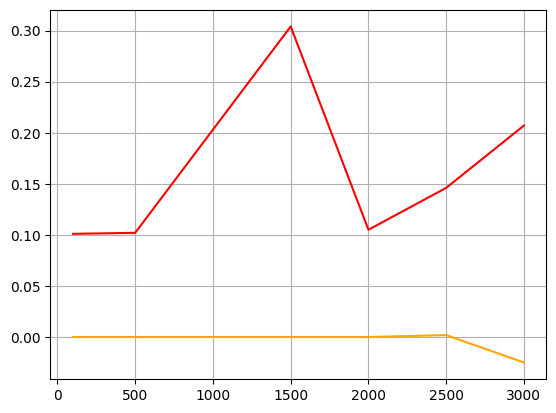

In [99]:
fig, ax = plt.subplots()
# line1 = ax.plot(report.raw_table['user_count'], report.raw_table['proc_errors'])
ax.grid(True)
line2 = ax.plot(report.raw_table['user_count'], normalized_data_list, color='red')
line3 = ax.plot(report.raw_table['user_count'], func_proc_erros, color='orange')

In [100]:
###

In [101]:
data = report.raw_table.drop(report.raw_table.columns[-2:], axis=1)
data

,user_count,proc_errors,sr_znach,value_for_last_proc_delay
0,100,10.1,1.312312,1.312312
1,500,10.2,2.688386,2.783788
2,1000,20.3,8.900948,8.856661
3,1500,30.4,13.264277,13.264441
4,2000,10.5,20.667529,20.456359
5,2500,14.6,25.474788,25.585479
6,3000,20.7,30.163161,30.351173


In [102]:
report.get_rating_proc_errors(auto_normalize=False)

(53827.993566433, 51320.083333333336)

In [103]:
func_proc_erros_base = report.data_aproximation(ox_lst, oy_lst[1:-1])
func_proc_erros_base

poly1d([-2.45861061e-17,  2.15487447e-13, -6.99642141e-10,  1.03218183e-06,
       -6.85489766e-04,  1.84842430e-01, -2.49369328e+00])

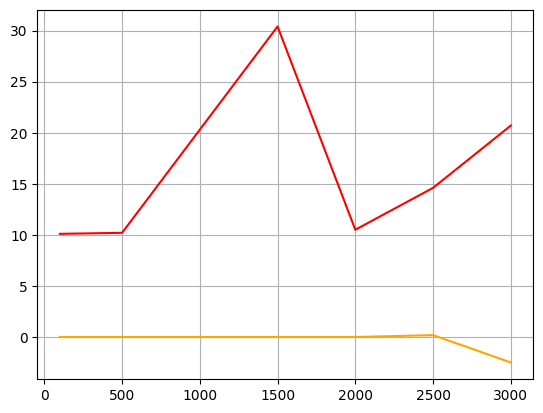

In [104]:
fig, ax = plt.subplots()
# line1 = ax.plot(report.raw_table['user_count'], report.raw_table['proc_errors'])
ax.grid(True)
line2 = ax.plot(data['user_count'], data['proc_errors'], color='red')
line3 = ax.plot(data['user_count'], func_proc_erros_base, color='orange')

In [105]:
ox_lst

[100, 500, 1000, 1500, 2000, 2500, 3000]

In [106]:
oy_lst[1:-1]

[10.1, 10.2, 20.3, 30.4, 10.5, 14.6, 20.7]

In [107]:
from scipy.optimize import curve_fit

In [108]:
x = np.array([100, 500, 1000, 1500, 2000, 2500, 3000])
y = np.array([10.1, 10.2, 20.3, 30.4, 10.5, 14.6, 20.7])

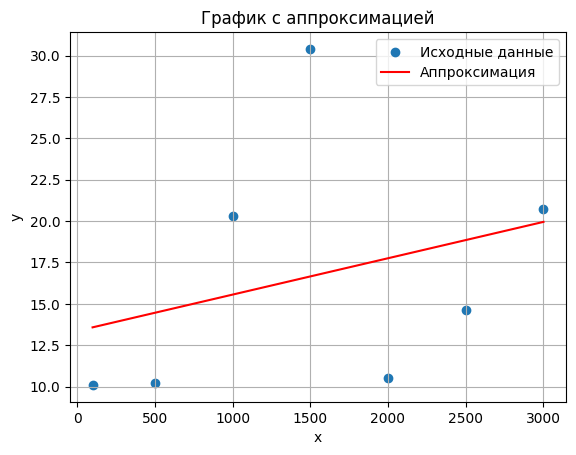

In [109]:
# Функция для аппроксимации (например, линейная)
def linear_func(x, a, b):
    return a * x + b

# Аппроксимация данных
params, _ = curve_fit(linear_func, x, y)
a, b = params

# Генерация точек для аппроксимированной линии
x_fit = np.linspace(min(x), max(x), 100)
y_fit = linear_func(x_fit, a, b)

plt.scatter(x, y, label='Исходные данные')
plt.plot(x_fit, y_fit, label='Аппроксимация', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('График с аппроксимацией')
plt.legend()
plt.grid(True)

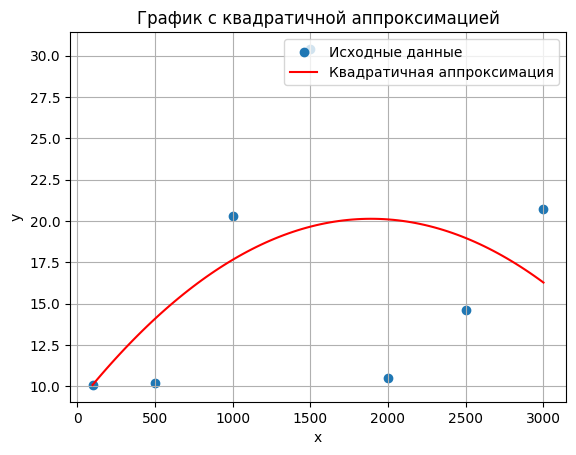

In [110]:
# Функция для квадратичной аппроксимации
def quadratic_func(x, a, b, c):
    return a * x**2 + b * x + c

# Аппроксимация данных
params, _ = curve_fit(quadratic_func, x, y)
a, b, c = params

# Генерация точек для аппроксимированной кривой
x_fit = np.linspace(min(x), max(x), 100)
y_fit = quadratic_func(x_fit, a, b, c)

plt.scatter(x, y, label='Исходные данные')
plt.plot(x_fit, y_fit, label='Квадратичная аппроксимация', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('График с квадратичной аппроксимацией')
plt.legend()
plt.grid(True)

/home/ivelikanov/git/stress_test/freeipa/venv/lib/python3.7/site-packages/scipy/optimize/minpack.py:834: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


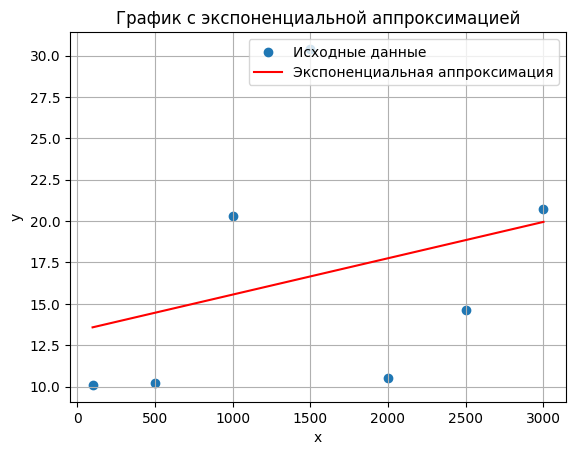

In [111]:
# Функция для экспоненциальной аппроксимации
def exponential_func(x, a, b, c):
    return a * np.exp(b * x) + c

# Аппроксимация данных
params, _ = curve_fit(exponential_func, x, y, p0=[1, 0.001, 10])  # Начальные параметры для лучшей сходимости
a, b, c = params

# Генерация точек для аппроксимированной кривой
x_fit = np.linspace(min(x), max(x), 100)
y_fit = exponential_func(x_fit, a, b, c)

plt.scatter(x, y, label='Исходные данные')
plt.plot(x_fit, y_fit, label='Экспоненциальная аппроксимация', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('График с экспоненциальной аппроксимацией')
plt.legend()
plt.grid(True)
plt.show()

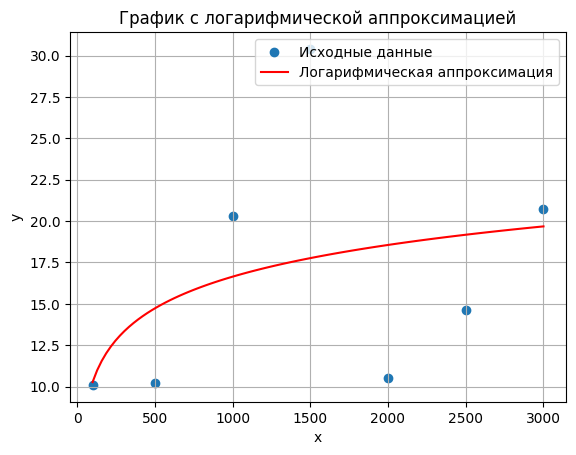

In [112]:
# Функция для логарифмической аппроксимации
def logarithmic_func(x, a, b):
    return a * np.log(x) + b

# Аппроксимация данных
params, _ = curve_fit(logarithmic_func, x, y)
a, b = params

# Генерация точек для аппроксимированной кривой
x_fit = np.linspace(min(x), max(x), 100)
y_fit = logarithmic_func(x_fit, a, b)

plt.scatter(x, y, label='Исходные данные')
plt.plot(x_fit, y_fit, label='Логарифмическая аппроксимация', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('График с логарифмической аппроксимацией')
plt.legend()
plt.grid(True)

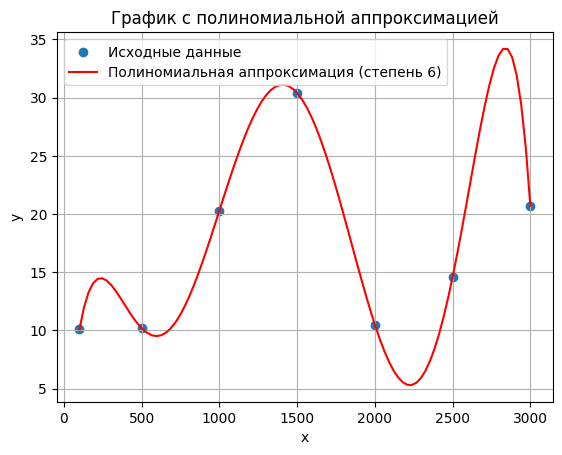

In [113]:
# Полиномиальная аппроксимация (степень 3)
degree = 6  # Можно изменить степень полинома
coefficients = np.polyfit(x, y, degree)  # Находим коэффициенты полинома
poly_func = np.poly1d(coefficients)  # Создаем функцию полинома

# Генерация точек для аппроксимированной кривой
x_fit = np.linspace(min(x), max(x), 100)
y_fit = poly_func(x_fit)

plt.scatter(x, y, label='Исходные данные')
plt.plot(x_fit, y_fit, label=f'Полиномиальная аппроксимация (степень {degree})', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('График с полиномиальной аппроксимацией')
plt.legend()
plt.grid(True)